<a href="https://colab.research.google.com/github/leonardomenezes10/Fundamentos/blob/main/notebooks/china/MFA_China.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Importação e Instalação

In [ ]:
!pip install tinydb

In [ ]:
# programas/bibliotecas utilizados no script/codigo
import httpx # Responsável pelas requisições web
from bs4 import BeautifulSoup # Responsável por realizar o web scraping (coletar os dados)
from tinydb import TinyDB, Query

## Criação do banco json

In [ ]:
def inserir_no_banco(MFA_NEWS, link_news):
  arquivo_banco_dados = "nota_mfa.json"
  db = TinyDB(arquivo_banco_dados)


  # Evitar dados repetidos no banco
  Buscar = Query()
  verificar_link = db.contains(Buscar.link == link_news)

  if not verificar_link:
    print("Inserindo nova informação no banco")
    db.insert(MFA_NEWS)
  else:
    print("Link já existe no banco. Esta informação não será inserida novamente")

In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

#baseurl = 'http://fmprc.gov.cn/eng/gjhdq_665435/3447_665449/3473_665008/3475_665012/index_3.html'

headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/146.0.0.0 Safari/537.36'
}


for x in range (1, 11):
  pages = (f'https://www.fmprc.gov.cn/eng/gjhdq_665435/3447_665449/3473_665008/3475_665012/index_{x}.html')
  #print(pages)


  r = requests.get(pages)
  soup = BeautifulSoup(r.content, 'lxml')
  newslist = soup.find('div', class_='news_list').find_all("div")

  full_list = []
  for news in newslist:
    if news.a: # Added check here
      url_base = 'https://www.fmprc.gov.cn/eng/gjhdq_665435/3447_665449/3473_665008/3475_665012'
      link_news = url_base + news.a['href'][1:]
      #print(link_news)


      r = requests.get(link_news)
      soup = BeautifulSoup(r.content, 'lxml')
      title = soup.find('div', class_='news_header').find('div', class_='news_header_title').text
      #print(title)


      data = soup.find('span', class_='xltime').text
      #print(data)


      atributo_style_01 = "text-indent: 0px;"
      atributo_style_02 = "margin: 0px 0px 20px;border: 0px;padding: 0px;box-sizing: border-box;overflow-wrap: break-word;font-family: Georgia;font-size: 20px;text-align: justify;text-wrap-mode: wrap"
      conteudo = soup.find("div", attrs={"class": "content_text"}).find_all('p')
      paragrafos = []
      for tag_p in conteudo:
        paragrafo = tag_p.text
        paragrafos.append(paragrafo)
      #print(paragrafos)
      #print("###")

      MFA_NEWS = {
        'title': title,
        'data': data,
        'link': link_news,
        'paragrafos': paragrafos
      }
      print(MFA_NEWS)

      full_list.append(MFA_NEWS)
      inserir_no_banco(MFA_NEWS, link_news)

      #print('Saving: ', MFA_NEWS['title'])
#df = pd.DataFrame(full_list)
#print(df.head(15))

#df.head(15)
#df.to_csv('news.csv', index=False)



      #newslist.append(paragrafos)


{'title': 'Wang Yi Has a Phone Call with Brazilian Foreign Minister Mauro Vieira', 'data': 'August 29, 2025 03:50', 'link': 'https://www.fmprc.gov.cn/eng/gjhdq_665435/3447_665449/3473_665008/3475_665012/202508/t20250829_11698217.html', 'paragrafos': ["On August 28, 2025, Member of the Political Bureau of the CPC Central Committee and Foreign Minister Wang Yi had a phone call with Brazilian Foreign Minister Mauro Vieira at the latter's request.", 'Wang Yi said that the China-Brazil relationship is at its best in history. President Xi Jinping and President Luiz Inácio Lula da Silva have forged solid mutual trust and friendship, and jointly provided important strategic guidance for the building of a China-Brazil community with a shared future. China is ready to work with Brazil to strengthen strategic mutual trust, firmly support each other, accelerate the implementation of the important common understandings reached by the two heads of state, and deepen practical cooperation in various f

# Transformar banco json e dataframe

- pre-analise - entendimento geral sobre o dataframe

In [ ]:
import pandas as pd
import json

## Abrindo o rquivo json
with open("nota_mfa.json") as f:
  raw = json.load(f)

df = pd.DataFrame.from_dict(raw["_default"], orient="index")

df


,title,data,link,paragrafos
1,Wang Yi Has a Phone Call with Brazilian Foreig...,"August 29, 2025 03:50",https://www.fmprc.gov.cn/eng/gjhdq_665435/3447...,"[On August 28, 2025, Member of the Political B..."
2,Xi Jinping Has a Phone Call with Brazilian Pre...,"August 12, 2025 13:05",https://www.fmprc.gov.cn/eng/gjhdq_665435/3447...,"[On August 12, President Xi Jinping had a phon..."
3,Wang Yi Has a Phone Call with Brazilian Chief ...,"August 06, 2025 16:40",https://www.fmprc.gov.cn/eng/gjhdq_665435/3447...,"[On August 6, 2025, Member of the Political Bu..."
4,Remarks by Chinese Premier Li Qiang at the ses...,"July 07, 2025 13:45",https://www.fmprc.gov.cn/eng/gjhdq_665435/3447...,[Chinese Premier Li Qiang delivered a speech o...
5,Head of the Department of Security Cooperation...,"June 10, 2025 21:17",https://www.fmprc.gov.cn/eng/gjhdq_665435/3447...,"[On June 6, 2025, Director-General of the Depa..."
...,...,...,...,...
66,Wang Yi Meets with Chief Advisor of the Presid...,"April 13, 2023 23:55",https://www.fmprc.gov.cn/eng/gjhdq_665435/3447...,"[, On April 13, 2023, Member of the Political ..."
67,Xi Jinping Sends Message of Sympathy to Brazil...,"March 26, 2023 21:12",https://www.fmprc.gov.cn/eng/gjhdq_665435/3447...,"[On March 26, 2023, President Xi Jinping sent ..."
68,Qin Gang Meets with Brazilian Minister of Fore...,"March 02, 2023 22:35",https://www.fmprc.gov.cn/eng/gjhdq_665435/3447...,"[, On March 2, 2023 local time, Foreign Minist..."
69,Xi Jinping Sends Message of Condolence to Braz...,"February 22, 2023 21:55",https://www.fmprc.gov.cn/eng/gjhdq_665435/3447...,"[On February 22, 2023, President Xi Jinping se..."


In [ ]:
# saber quantidade de linhas e colunas do dataframe
df.shape

(70, 4)

In [ ]:
# saber colunas disponiveis
df.columns

Index(['title', 'data', 'link', 'paragrafos'], dtype='object')

In [ ]:
# selecionar uma coluna em especifico
df["title"]

,title
1,Wang Yi Has a Phone Call with Brazilian Foreig...
2,Xi Jinping Has a Phone Call with Brazilian Pre...
3,Wang Yi Has a Phone Call with Brazilian Chief ...
4,Remarks by Chinese Premier Li Qiang at the ses...
5,Head of the Department of Security Cooperation...
...,...
66,Wang Yi Meets with Chief Advisor of the Presid...
67,Xi Jinping Sends Message of Sympathy to Brazil...
68,Qin Gang Meets with Brazilian Minister of Fore...
69,Xi Jinping Sends Message of Condolence to Braz...


In [ ]:

# delimitar colunas do dataframe
df_delimitado = df[["title", "data"]]
df_delimitado

,title,data
1,Wang Yi Has a Phone Call with Brazilian Foreig...,"August 29, 2025 03:50"
2,Xi Jinping Has a Phone Call with Brazilian Pre...,"August 12, 2025 13:05"
3,Wang Yi Has a Phone Call with Brazilian Chief ...,"August 06, 2025 16:40"
4,Remarks by Chinese Premier Li Qiang at the ses...,"July 07, 2025 13:45"
5,Head of the Department of Security Cooperation...,"June 10, 2025 21:17"
...,...,...
66,Wang Yi Meets with Chief Advisor of the Presid...,"April 13, 2023 23:55"
67,Xi Jinping Sends Message of Sympathy to Brazil...,"March 26, 2023 21:12"
68,Qin Gang Meets with Brazilian Minister of Fore...,"March 02, 2023 22:35"
69,Xi Jinping Sends Message of Condolence to Braz...,"February 22, 2023 21:55"


In [ ]:

# primeiras (head), ultimas (tail) e linhas aleatórias (sample)
df.head(10)

,title,data,link,paragrafos
1,Wang Yi Has a Phone Call with Brazilian Foreig...,"August 29, 2025 03:50",https://www.fmprc.gov.cn/eng/gjhdq_665435/3447...,"[On August 28, 2025, Member of the Political B..."
2,Xi Jinping Has a Phone Call with Brazilian Pre...,"August 12, 2025 13:05",https://www.fmprc.gov.cn/eng/gjhdq_665435/3447...,"[On August 12, President Xi Jinping had a phon..."
3,Wang Yi Has a Phone Call with Brazilian Chief ...,"August 06, 2025 16:40",https://www.fmprc.gov.cn/eng/gjhdq_665435/3447...,"[On August 6, 2025, Member of the Political Bu..."
4,Remarks by Chinese Premier Li Qiang at the ses...,"July 07, 2025 13:45",https://www.fmprc.gov.cn/eng/gjhdq_665435/3447...,[Chinese Premier Li Qiang delivered a speech o...
5,Head of the Department of Security Cooperation...,"June 10, 2025 21:17",https://www.fmprc.gov.cn/eng/gjhdq_665435/3447...,"[On June 6, 2025, Director-General of the Depa..."
6,Li Qiang Meets with Brazilian President Luiz I...,"May 13, 2025 23:00",https://www.fmprc.gov.cn/eng/gjhdq_665435/3447...,"[, On the afternoon of May 13, 2025, Premier L..."
7,Peng Liyuan and Wife of Brazilian President Ro...,"May 13, 2025 23:50",https://www.fmprc.gov.cn/eng/gjhdq_665435/3447...,"[, On the afternoon of May 13, 2025, Peng Liyu..."
8,Wang Yi Meets with Brazilian Foreign Minister ...,"May 13, 2025 23:00",https://www.fmprc.gov.cn/eng/gjhdq_665435/3447...,"[, On May 12, 2025, Member of the Political Bu..."
9,Xi Jinping Holds Talks with Brazilian Presiden...,"May 13, 2025 22:55",https://www.fmprc.gov.cn/eng/gjhdq_665435/3447...,"[, On the afternoon of May 13, 2025, President..."
10,Zhao Leji Meets with Brazilian President Luiz ...,"May 13, 2025 23:30",https://www.fmprc.gov.cn/eng/gjhdq_665435/3447...,"[On the afternoon of May 13, 2025, Chairman of..."


In [ ]:
df.describe(include="all")

,title,data,link,paragrafos
count,70,70,70,70
unique,63,64,70,69
top,Wang Yi Meets with Brazilian Foreign Minister ...,"April 30, 2025 23:00",https://www.fmprc.gov.cn/eng/gjhdq_665435/3447...,"[, On the afternoon of June 7, 2024, President..."
freq,3,3,1,2


### Tratamento de Dados e Visualização

Agora que entendemos a estrutura, vamos preparar os dados para extrair insights visuais. Um passo comum é converter colunas de texto em formatos que o computador entenda como 'tempo' (datetime) e criar gráficos.

In [ ]:
# 1. Converter a coluna de data para o formato datetime do Pandas
df['data_dt'] = pd.to_datetime(df['data'], dayfirst=True)

# 2. Contar quantas notícias temos por dia
noticias_por_dia = df['data_dt'].value_counts().sort_index()

display(noticias_por_dia)

,count
data_dt,
2023-01-18 23:00:00,1
2023-02-22 21:55:00,1
2023-03-02 22:35:00,1
2023-03-26 21:12:00,1
2023-04-13 23:55:00,1
...,...
2025-06-10 21:17:00,1
2025-07-07 13:45:00,1
2025-08-06 16:40:00,1


#### Visualizando o Volume de Publicações

Vamos usar a biblioteca `matplotlib` (que já vem no ambiente) para criar um gráfico de barras simples.

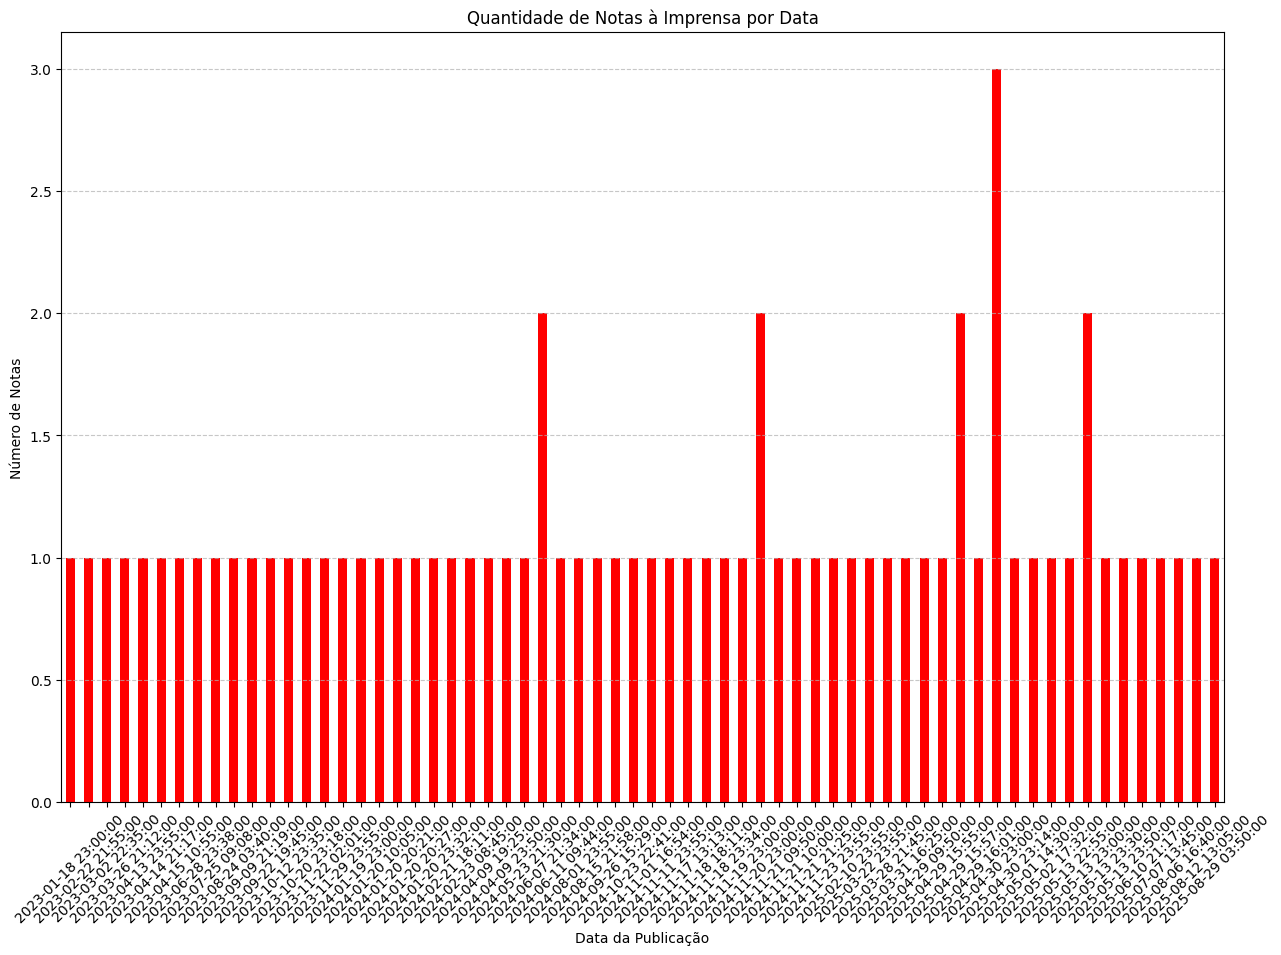

In [ ]:
import matplotlib.pyplot as plt

# Criando o gráfico
plt.figure(figsize=(15, 10))
noticias_por_dia.plot(kind='bar', color='red')

# Adicionando títulos e rótulos
plt.title('Quantidade de Notas à Imprensa por Data')
plt.xlabel('Data da Publicação')
plt.ylabel('Número de Notas')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

#### Analisando Palavras-Chave nos Títulos

Uma técnica simples de análise de texto para iniciantes é verificar a frequência de certas palavras-chave (como nomes de países).

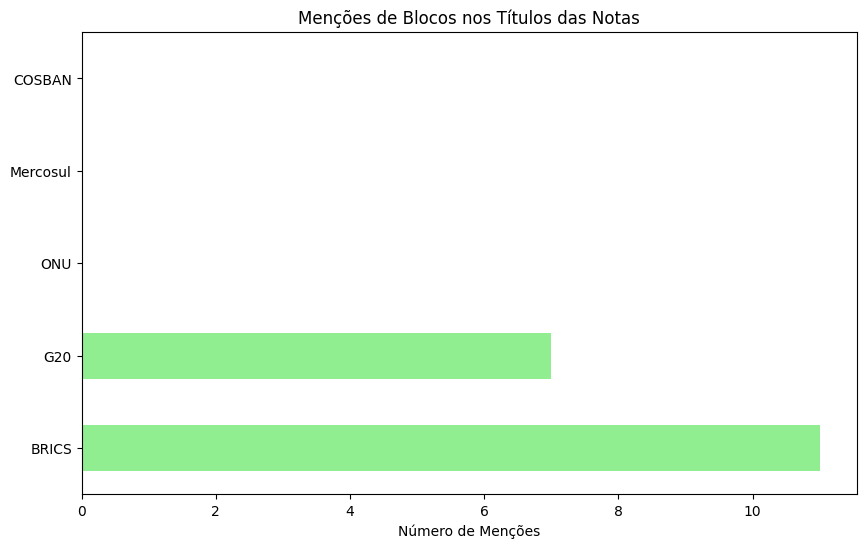

In [ ]:
blocos = ['BRICS', 'G20', 'ONU', 'Mercosul', 'COSBAN']
frequencia = {}

for bloco in blocos:
    # Conta em quantos títulos a palavra aparece
    frequencia[bloco] = df['title'].str.contains(bloco, case=False).sum()

# Converter para série para facilitar a plotagem
ser_freq = pd.Series(frequencia)

plt.figure(figsize=(10, 6))
ser_freq.sort_values(ascending=False).plot(kind='barh', color='lightgreen')
plt.title('Menções de Blocos nos Títulos das Notas')
plt.xlabel('Número de Menções')
plt.show()

---

# 📊 Visualização avançada dos dados

Nesta parte vamos:

1. **Preparar** os dados (corrigir tipos, criar colunas auxiliares)
2. **Buscar** por termos e palavras-chave (no título e no corpo da nota)
3. **Analisar** frequência de termos (países, temas, organizações)
4. **Visualizar** o volume de publicações no tempo
5. **Acompanhar** um tema específico ao longo do tempo
6. **Gerar** nuvens de palavras (word cloud)
7. **Examinar** o tamanho das notas
8. **Descobrir** co-ocorrências (quais países aparecem juntos)


## 1. Preparação dos dados

Antes de visualizar, precisamos arrumar algumas coisas:

- A coluna `data` está como **texto** (`"22/04/2026"`). Vamos transformar em **datetime** para conseguir agrupar por mês, dia da semana, etc.
- A coluna `paragrafo` contém **listas** de strings — por isso `df.duplicated()` deu erro mais acima. Vamos juntar os parágrafos em um único texto na coluna `texto`.
- Vamos criar uma coluna `texto_completo` com título + corpo, em minúsculas, para facilitar buscas case-insensitive.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1.1 — Converter data para datetime (dayfirst pq é formato brasileiro: dd/mm/aaaa)
df['data_dt'] = pd.to_datetime(df['data'], dayfirst=True, errors='coerce')

# 1.2 — Juntar os parágrafos (que são listas) em um único texto
df['texto'] = df['paragrafos'].apply(lambda lista: ' '.join(lista) if isinstance(lista, list) else str(lista))

# 1.3 — Coluna com tudo junto e em minúsculas (facilita buscas)
df['texto_completo'] = (df['title'].fillna('') + ' ' + df['texto']).str.lower()

# 1.5 — Colunas auxiliares de tempo
df['ano_mes'] = df['data_dt'].dt.to_period('M')
df['dia_semana'] = df['data_dt'].dt.day_name()
df['tamanho_texto'] = df['texto'].str.len()
df['qtd_paragrafos'] = df['paragrafos'].apply(lambda x: len(x) if isinstance(x, list) else 0)

print(f"Total de notas: {len(df)}")
print(f"Período: de {df['data_dt'].min().date()} até {df['data_dt'].max().date()}")
df[['title', 'data_dt', 'qtd_paragrafos', 'tamanho_texto']].head()


Total de notas: 70
Período: de 2023-01-18 até 2025-08-29


,title,data_dt,qtd_paragrafos,tamanho_texto
1,Wang Yi Has a Phone Call with Brazilian Foreig...,2025-08-29 03:50:00,4,2006
2,Xi Jinping Has a Phone Call with Brazilian Pre...,2025-08-12 13:05:00,4,2252
3,Wang Yi Has a Phone Call with Brazilian Chief ...,2025-08-06 16:40:00,6,4233
4,Remarks by Chinese Premier Li Qiang at the ses...,2025-07-07 13:45:00,16,6222
5,Head of the Department of Security Cooperation...,2025-06-10 21:17:00,3,1174


### 1.1 Verificar duplicatas

Como a coluna `paragrafo` é uma lista, ela quebra o `df.duplicated()`. Solução: verificar duplicatas só nas colunas que importam (link, título).


In [ ]:
# Duplicatas por link (cada nota deveria ter um link único)
print("Duplicatas por link:", df.duplicated(subset=['link']).sum())

# Duplicatas por título
print("Duplicatas por título:", df.duplicated(subset=['title']).sum())


Duplicatas por link: 0
Duplicatas por título: 7


## 2. 🔍 Busca por termos e palavras-chave

A busca anterior só olhava o **título**. Vamos criar uma função que busca no **título e/ou no corpo** da nota, mostrando quantas notas mencionam o termo e permitindo ver os resultados.


In [ ]:
def buscar_termo(termo, onde='completo', mostrar=5):
    """
    Busca um termo nas notas do MRE.

    Parâmetros:
        termo (str): palavra ou expressão a buscar (não diferencia maiúsc/minúsc)
        onde (str): 'titulo', 'texto' ou 'completo' (título + corpo)
        mostrar (int): quantos resultados imprimir

    Retorna:
        DataFrame com as notas que contêm o termo
    """
    coluna = {
        'title': 'title',
        'texto': 'texto',
        'completo': 'texto_completo',
    }[onde]

    # busca case-insensitive; na=False ignora valores faltantes
    mascara = df[coluna].str.contains(termo, case=False, na=False, regex=False)
    resultado = df[mascara].sort_values('data_dt', ascending=False)

    print(f"🔎 Termo: '{termo}'  |  Onde: {onde}")
    print(f"📌 Notas encontradas: {len(resultado)} de {len(df)} ({len(resultado)/len(df)*100:.1f}%)")
    print("-" * 60)

    for _, row in resultado.head(mostrar).iterrows():
        data_str = row['data_dt'].strftime('%d/%m/%Y') if pd.notna(row['data_dt']) else '?'
        print(f"  • [{data_str}] {row['title']}")

    if len(resultado) > mostrar:
        print(f"  ... e mais {len(resultado) - mostrar} nota(s)")

    return resultado


# Exemplos de uso:
res = buscar_termo('visit', onde='completo', mostrar=5)


🔎 Termo: 'visit'  |  Onde: completo
📌 Notas encontradas: 35 de 70 (50.0%)
------------------------------------------------------------
  • [13/05/2025] Peng Liyuan and Wife of Brazilian President Rosângela Lula da Silva Visit National Centre for the Performing Arts
  • [13/05/2025] Zhao Leji Meets with Brazilian President Luiz Inácio Lula da Silva
  • [13/05/2025] Li Qiang Meets with Brazilian President Luiz Inácio Lula da Silva
  • [13/05/2025] Wang Yi Meets with Brazilian Foreign Minister Mauro Vieira and Chief Advisor to the Presidency Celso Luiz Nunes Amorim
  • [13/05/2025] Xi Jinping Holds Talks with Brazilian President Luiz Inácio Lula da Silva
  ... e mais 30 nota(s)


In [ ]:
# Buscar só no título
buscar_termo('governance', onde='title', mostrar=5)


🔎 Termo: 'governance'  |  Onde: title
📌 Notas encontradas: 3 de 70 (4.3%)
------------------------------------------------------------
  • [07/07/2025] Remarks by Chinese Premier Li Qiang at the session on peace and security and global governance reform of the XVII BRICS Summit
  • [29/04/2025] Making BRICS Contribution to the Reform and Improvement of Global Governance
  • [29/04/2025] Wang Yi: Uphold BRICS Unity and Cooperation, Reform and Improve Global Governance


,title,data,link,paragrafos,data_dt,texto,texto_completo,ano_mes,dia_semana,tamanho_texto,qtd_paragrafos
4,Remarks by Chinese Premier Li Qiang at the ses...,"July 07, 2025 13:45",https://www.fmprc.gov.cn/eng/gjhdq_665435/3447...,[Chinese Premier Li Qiang delivered a speech o...,2025-07-07 13:45:00,Chinese Premier Li Qiang delivered a speech on...,remarks by chinese premier li qiang at the ses...,2025-07,Monday,6222,16
12,Making BRICS Contribution to the Reform and Im...,"April 29, 2025 16:01",https://www.fmprc.gov.cn/eng/gjhdq_665435/3447...,[Remarks by H.E. Wang YiAt the Session “Reform...,2025-04-29 16:01:00,Remarks by H.E. Wang YiAt the Session “Reformi...,making brics contribution to the reform and im...,2025-04,Tuesday,5204,11
20,"Wang Yi: Uphold BRICS Unity and Cooperation, R...","April 29, 2025 15:57",https://www.fmprc.gov.cn/eng/gjhdq_665435/3447...,"[On April 28, 2025 local time, Member of the P...",2025-04-29 15:57:00,"On April 28, 2025 local time, Member of the Po...","wang yi: uphold brics unity and cooperation, r...",2025-04,Tuesday,3047,6


In [ ]:
# Buscar uma expressão composta
buscar_termo('BRICS', onde='completo', mostrar=5)


🔎 Termo: 'BRICS'  |  Onde: completo
📌 Notas encontradas: 36 de 70 (51.4%)
------------------------------------------------------------
  • [29/08/2025] Wang Yi Has a Phone Call with Brazilian Foreign Minister Mauro Vieira
  • [12/08/2025] Xi Jinping Has a Phone Call with Brazilian President Luiz Inácio Lula da Silva
  • [06/08/2025] Wang Yi Has a Phone Call with Brazilian Chief Advisor to the Presidency Celso Luiz Nunes Amorim
  • [07/07/2025] Remarks by Chinese Premier Li Qiang at the session on peace and security and global governance reform of the XVII BRICS Summit
  • [10/06/2025] Head of the Department of Security Cooperation of the Foreign Ministry Leads A Delegation to Attend the Tenth Meeting of the BRICS Counter-Terrorism Working Group
  ... e mais 31 nota(s)


,title,data,link,paragrafos,data_dt,texto,texto_completo,ano_mes,dia_semana,tamanho_texto,qtd_paragrafos
1,Wang Yi Has a Phone Call with Brazilian Foreig...,"August 29, 2025 03:50",https://www.fmprc.gov.cn/eng/gjhdq_665435/3447...,"[On August 28, 2025, Member of the Political B...",2025-08-29 03:50:00,"On August 28, 2025, Member of the Political Bu...",wang yi has a phone call with brazilian foreig...,2025-08,Friday,2006,4
2,Xi Jinping Has a Phone Call with Brazilian Pre...,"August 12, 2025 13:05",https://www.fmprc.gov.cn/eng/gjhdq_665435/3447...,"[On August 12, President Xi Jinping had a phon...",2025-08-12 13:05:00,"On August 12, President Xi Jinping had a phone...",xi jinping has a phone call with brazilian pre...,2025-08,Tuesday,2252,4
3,Wang Yi Has a Phone Call with Brazilian Chief ...,"August 06, 2025 16:40",https://www.fmprc.gov.cn/eng/gjhdq_665435/3447...,"[On August 6, 2025, Member of the Political Bu...",2025-08-06 16:40:00,"On August 6, 2025, Member of the Political Bur...",wang yi has a phone call with brazilian chief ...,2025-08,Wednesday,4233,6
4,Remarks by Chinese Premier Li Qiang at the ses...,"July 07, 2025 13:45",https://www.fmprc.gov.cn/eng/gjhdq_665435/3447...,[Chinese Premier Li Qiang delivered a speech o...,2025-07-07 13:45:00,Chinese Premier Li Qiang delivered a speech on...,remarks by chinese premier li qiang at the ses...,2025-07,Monday,6222,16
5,Head of the Department of Security Cooperation...,"June 10, 2025 21:17",https://www.fmprc.gov.cn/eng/gjhdq_665435/3447...,"[On June 6, 2025, Director-General of the Depa...",2025-06-10 21:17:00,"On June 6, 2025, Director-General of the Depar...",head of the department of security cooperation...,2025-06,Tuesday,1174,3
9,Xi Jinping Holds Talks with Brazilian Presiden...,"May 13, 2025 22:55",https://www.fmprc.gov.cn/eng/gjhdq_665435/3447...,"[, On the afternoon of May 13, 2025, President...",2025-05-13 22:55:00,"On the afternoon of May 13, 2025, President X...",xi jinping holds talks with brazilian presiden...,2025-05,Tuesday,6763,18
11,Holding High the Banner of Multilateralism and...,"May 02, 2025 17:32",https://www.fmprc.gov.cn/eng/gjhdq_665435/3447...,[Remarks by H.E. Wang YiAt the Session for Min...,2025-05-02 17:32:00,Remarks by H.E. Wang YiAt the Session for Mini...,holding high the banner of multilateralism and...,2025-05,Friday,7167,15
14,Brazilian President Luiz Inácio Lula da Silva ...,"May 01, 2025 14:30",https://www.fmprc.gov.cn/eng/gjhdq_665435/3447...,"[, On April 30, 2025 local time, Brazilian Pre...",2025-05-01 14:30:00,"On April 30, 2025 local time, Brazilian Presi...",brazilian president luiz inácio lula da silva ...,2025-05,Thursday,3325,10
18,"Wang Yi: The Times Brook No Regression, and Ju...","April 30, 2025 23:14",https://www.fmprc.gov.cn/eng/gjhdq_665435/3447...,"[On April 29, 2025 local time, Member of the P...",2025-04-30 23:14:00,"On April 29, 2025 local time, Member of the Po...","wang yi: the times brook no regression, and ju...",2025-04,Wednesday,1859,4
15,Wang Yi Meets with Chief Advisor to the Presid...,"April 30, 2025 23:00",https://www.fmprc.gov.cn/eng/gjhdq_665435/3447...,"[, On April 29, 2025 local time, Member of the...",2025-04-30 23:00:00,"On April 29, 2025 local time, Member of the P...",wang yi meets with chief advisor to the presid...,2025-04,Wednesday,3368,8


## 3. 📈 Frequência de vários termos comparados

Vamos generalizar a análise: em vez de fixar 5 países, comparamos qualquer lista de termos de interesse (países, organizações, temas) — buscando no texto **completo** (não só no título).


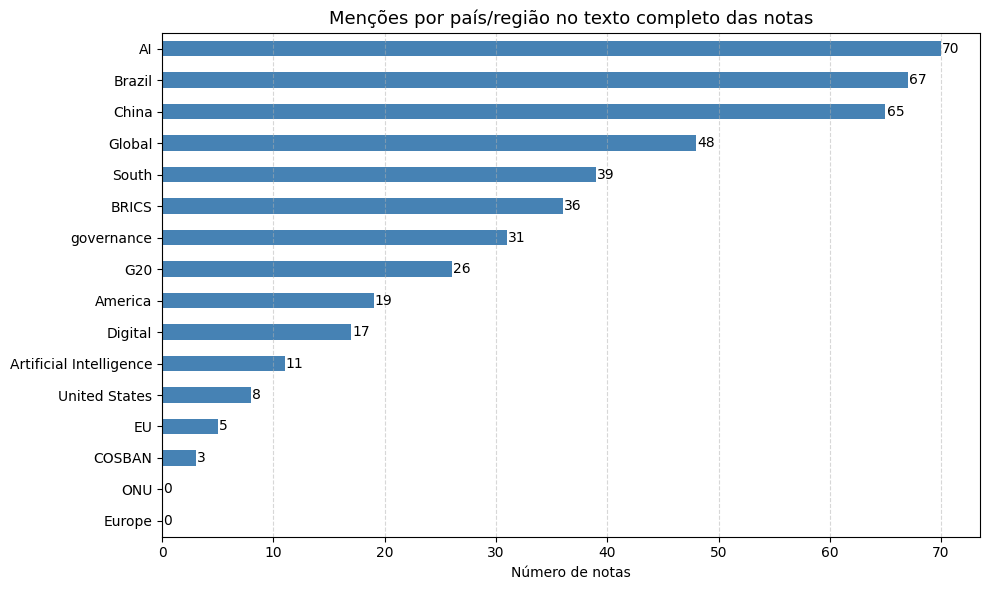

In [ ]:
def frequencia_termos(lista_termos, onde='completo'):
    """Conta em quantas notas cada termo da lista aparece."""
    coluna = {'titulo': 'titulo', 'texto': 'texto', 'completo': 'texto_completo'}[onde]
    freq = {}
    for termo in lista_termos:
        freq[termo] = df[coluna].str.contains(termo, case=False, na=False, regex=False).sum()
    return pd.Series(freq).sort_values(ascending=True)


# Lista mais ampla de países e temas
termos_interesse = [
    'governance', 'AI', 'Artificial Intelligence', 'Brazil', 'Global',
    'BRICS', 'China', 'G20', 'South', 'America',
    'Digital', 'ONU', 'Europe', 'United States', 'EU', 'COSBAN'
]

freq = frequencia_termos(termos_interesse, onde='completo')

# Gráfico
fig, ax = plt.subplots(figsize=(10, 6))
freq.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Menções por país/região no texto completo das notas', fontsize=13)
ax.set_xlabel('Número de notas')
ax.grid(axis='x', linestyle='--', alpha=0.5)

# Anotar valores nas barras
for i, valor in enumerate(freq.values):
    ax.text(valor + 0.1, i, str(valor), va='center')

plt.tight_layout()
plt.show()


## 4. 🧠 Extração automática de palavras mais frequentes

Em vez de **definirmos** os termos, deixamos os dados falarem: quais palavras aparecem mais nos títulos? Para isso precisamos remover as **stopwords** (palavras muito comuns como "de", "da", "para") e palavras curtas.


Top 20 palavras nos TÍTULOS:
  meets                     22
  brics                     12
  mauro                     8
  vieira                    8
  chief                     8
  advisor                   8
  presidency                8
  nunes                     8
  summit                    8
  meeting                   7
  special                   7
  china                     7
  chinese                   6
  phone                     5
  call                      5
  ministers                 5
  government                5
  middle                    5
  east                      5
  state                     5


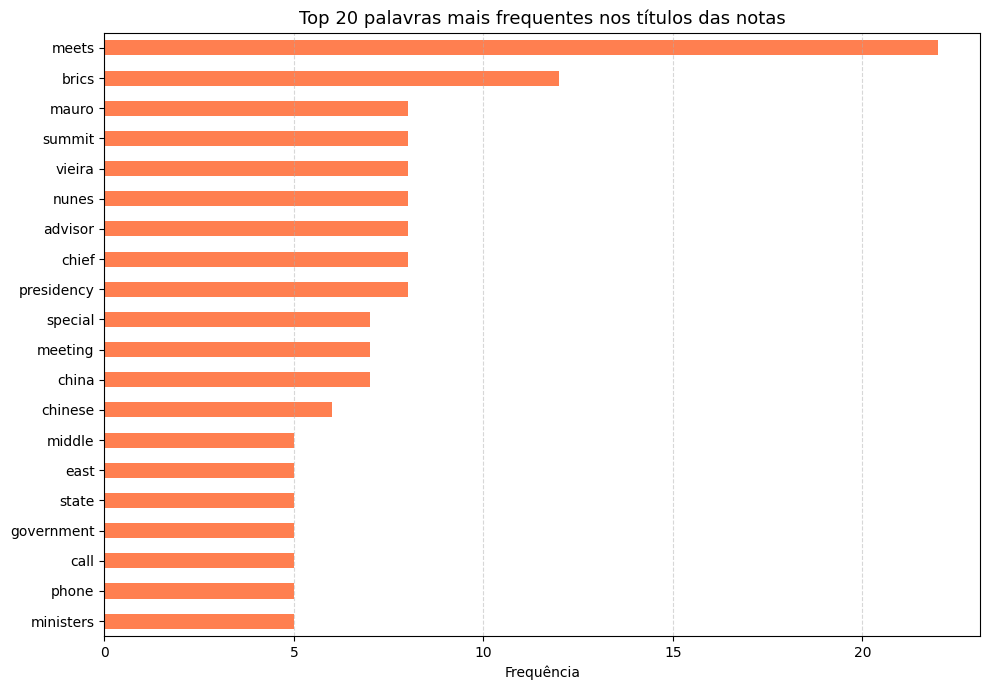

In [ ]:
import re
from collections import Counter

# Stopwords em português (lista pequena, suficiente para começar)
STOPWORDS_PT = {
    'with', 'brazilian', 'jinping', 'president', 'foreign', 'brazil', 'luiz', 'inácio',
    'lula', 'silva', 'da', 'amorim', 'wang', 'minister', 'attends', 'affairs', 'celso', 'nas',
    'e', 'ou', 'mas', 'que', 'se', 'por', 'para', 'com', 'sem',
    'à', 'ao', 'às', 'aos', 'pelo', 'pela', 'pelos', 'pelas',
    'é', 'são', 'foi', 'ser', 'estar', 'tem', 'ter', 'há',
    'sobre', 'entre', 'até', 'após', 'pela', 'pelo',
    'sua', 'seu', 'suas', 'seus', 'este', 'esta', 'isso', 'esse', 'essa',
    'nº', 'n°', 'nota', 'notas', 'imprensa',  # específicas do contexto
}


def palavras_mais_frequentes(serie_texto, top_n=20, min_tamanho=4):
    """Conta as palavras mais frequentes em uma coluna de texto."""
    todas_palavras = []
    for texto in serie_texto.dropna():
        # \w+ pega sequências de letras/números; flags re.UNICODE pra acentos
        palavras = re.findall(r'\b[a-záàâãéêíóôõúüç]+\b', texto.lower(), flags=re.UNICODE)
        palavras = [p for p in palavras if p not in STOPWORDS_PT and len(p) >= min_tamanho]
        todas_palavras.extend(palavras)
    return Counter(todas_palavras).most_common(top_n)


top_palavras = palavras_mais_frequentes(df['title'], top_n=20)
print("Top 20 palavras nos TÍTULOS:")
for palavra, contagem in top_palavras:
    print(f"  {palavra:25s} {contagem}")

# Gráfico
serie = pd.Series(dict(top_palavras)).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(10, 7))
serie.plot(kind='barh', ax=ax, color='coral')
ax.set_title('Top 20 palavras mais frequentes nos títulos das notas', fontsize=13)
ax.set_xlabel('Frequência')
ax.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


## 5. 🗓️ Análise temporal

O gráfico anterior ("notas por dia") fica difícil de ler quando há muitas datas. Vamos olhar em **agregações** mais úteis: por mês, por dia da semana, e por hora do dia.


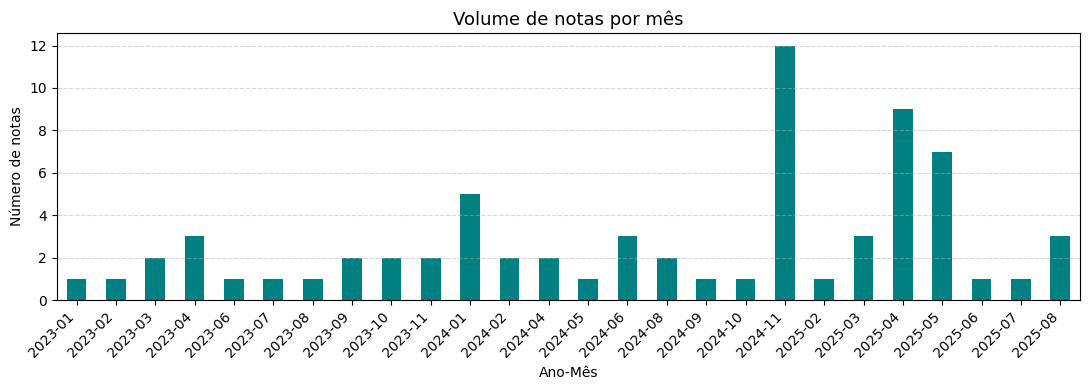

In [ ]:
# Notas por mês
notas_por_mes = df.groupby('ano_mes').size()

fig, ax = plt.subplots(figsize=(11, 4))
notas_por_mes.plot(kind='bar', ax=ax, color='teal')
ax.set_title('Volume de notas por mês', fontsize=13)
ax.set_xlabel('Ano-Mês')
ax.set_ylabel('Número de notas')
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


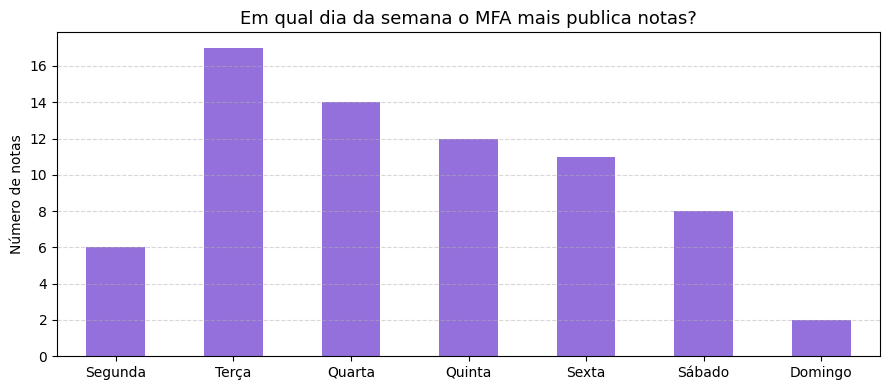

In [ ]:
# Notas por dia da semana (em português)
ordem_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
traducao_dias = {
    'Monday': 'Segunda', 'Tuesday': 'Terça', 'Wednesday': 'Quarta',
    'Thursday': 'Quinta', 'Friday': 'Sexta', 'Saturday': 'Sábado', 'Sunday': 'Domingo'
}

por_dia_semana = df['dia_semana'].value_counts().reindex(ordem_dias).fillna(0)
por_dia_semana.index = [traducao_dias[d] for d in por_dia_semana.index]

fig, ax = plt.subplots(figsize=(9, 4))
por_dia_semana.plot(kind='bar', ax=ax, color='mediumpurple')
ax.set_title('Em qual dia da semana o MFA mais publica notas?', fontsize=13)
ax.set_ylabel('Número de notas')
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [ ]:
# Notas por hora do dia
por_hora = df['hora_int'].dropna().astype(int).value_counts().sort_index()

fig, ax = plt.subplots(figsize=(11, 4))
por_hora.plot(kind='bar', ax=ax, color='goldenrod')
ax.set_title('Em qual hora do dia as notas são publicadas?', fontsize=13)
ax.set_xlabel('Hora (0–23)')
ax.set_ylabel('Número de notas')
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


KeyError: 'hora_int'

## 6. 📅 Acompanhar um tema ao longo do tempo

Combinando busca por termo + análise temporal: como evoluiu a menção a um país ou tema ao longo dos meses?


In [ ]:
def evolucao_termo(termo, onde='completo'):
    """Mostra quantas notas mencionam o termo por mês."""
    coluna = {'titulo': 'titulo', 'texto': 'texto', 'completo': 'texto_completo'}[onde]
    mascara = df[coluna].str.contains(termo, case=False, na=False, regex=False)
    return df[mascara].groupby('ano_mes').size()


# Comparar evolução de vários termos no tempo
termos_comparar = ['AI', 'China', 'Brazil', 'Governance']

fig, ax = plt.subplots(figsize=(11, 5))
for termo in termos_comparar:
    serie = evolucao_termo(termo)
    if len(serie) > 0:
        serie.plot(ax=ax, marker='o', label=termo)

ax.set_title('Menções por mês (no texto completo das notas)', fontsize=13)
ax.set_xlabel('Ano-Mês')
ax.set_ylabel('Número de notas que mencionam o termo')
ax.legend()
ax.grid(linestyle='--', alpha=0.5)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## 7. ☁️ Nuvem de palavras (word cloud)

Forma visual e divertida de ver os termos mais frequentes — quanto maior a palavra, mais ela aparece.

> ⚠️ Precisa instalar a biblioteca `wordcloud` (rode a próxima célula uma vez).


In [ ]:
!pip install wordcloud -q


In [ ]:
from wordcloud import WordCloud

# Junta todos os títulos em um único texto gigante
texto_titulos = ' '.join(df['title'].dropna()).lower()

# Remove stopwords usando o set já definido
wc = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    stopwords=STOPWORDS_PT,
    colormap='viridis',
    min_word_length=4,
    collocations=False,  # evita repetir bigramas
).generate(texto_titulos)

fig, ax = plt.subplots(figsize=(13, 6))
ax.imshow(wc, interpolation='bilinear')
ax.axis('off')
ax.set_title('Nuvem de palavras dos títulos das notas', fontsize=14)
plt.tight_layout()
plt.show()


## 8. 📏 Tamanho das notas

Quanto texto o MRE costuma escrever em cada nota? Algumas notas são bem curtas (ex: cumprimentos), outras são longas (declarações conjuntas, etc.).


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histograma de quantidade de parágrafos
df['qtd_paragrafos'].plot(kind='hist', bins=20, ax=axes[0], color='cornflowerblue', edgecolor='white')
axes[0].set_title('Distribuição: parágrafos por nota')
axes[0].set_xlabel('Número de parágrafos')
axes[0].set_ylabel('Quantidade de notas')
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# Histograma de tamanho do texto (em caracteres)
df['tamanho_texto'].plot(kind='hist', bins=20, ax=axes[1], color='salmon', edgecolor='white')
axes[1].set_title('Distribuição: tamanho do texto (caracteres)')
axes[1].set_xlabel('Caracteres')
axes[1].set_ylabel('Quantidade de notas')
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print("\n📊 Estatísticas:")
print(df[['qtd_paragrafos', 'tamanho_texto']].describe().round(1))


## 9. 🔗 Co-ocorrência de países

Quais países aparecem **juntos** numa mesma nota? Isso revela parcerias diplomáticas e contextos compartilhados (ex: declarações conjuntas).


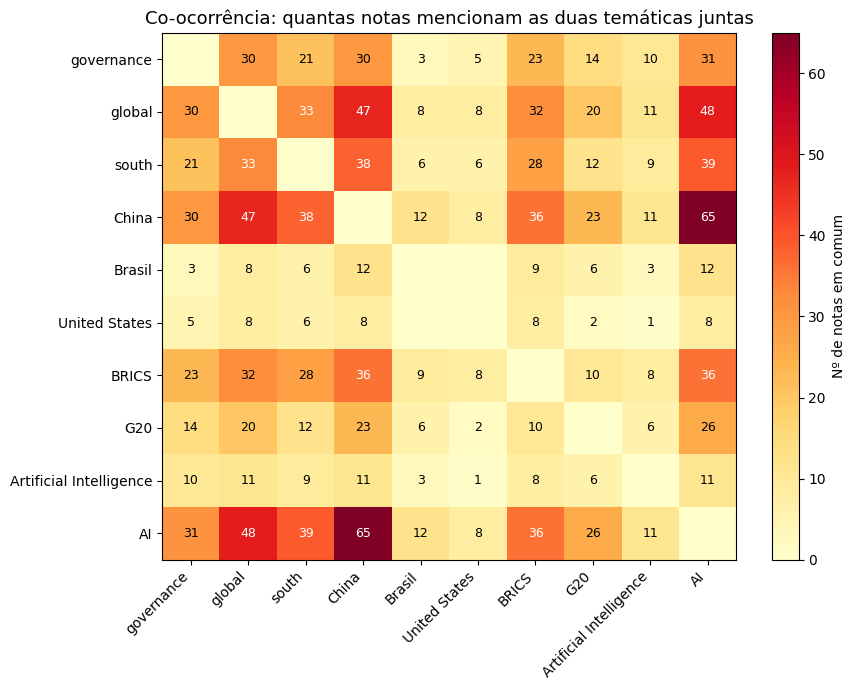

In [ ]:
import numpy as np

paises_analise = ['governance', 'global', 'south', 'China', 'Brasil',
                  'United States', 'BRICS', 'G20', 'Artificial Intelligence', 'AI']

# Para cada nota, marca quais países são mencionados
matriz_presenca = pd.DataFrame({
    pais: df['texto_completo'].str.contains(pais, case=False, na=False, regex=False).astype(int)
    for pais in paises_analise
})

# Matriz de co-ocorrência (multiplicação matricial: notas onde A E B aparecem)
coocorrencia = matriz_presenca.T.dot(matriz_presenca)

# Zerar a diagonal (não interessa um país com ele mesmo)
np.fill_diagonal(coocorrencia.values, 0)

# Heatmap simples com matplotlib
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(coocorrencia, cmap='YlOrRd', aspect='auto')

ax.set_xticks(range(len(paises_analise)))
ax.set_yticks(range(len(paises_analise)))
ax.set_xticklabels(paises_analise, rotation=45, ha='right')
ax.set_yticklabels(paises_analise)
ax.set_title('Co-ocorrência: quantas notas mencionam as duas temáticas juntas', fontsize=13)

# Anotar os valores nas células
for i in range(len(paises_analise)):
    for j in range(len(paises_analise)):
        valor = coocorrencia.iloc[i, j]
        if valor > 0:
            ax.text(j, i, int(valor), ha='center', va='center',
                    color='black' if valor < coocorrencia.values.max()/2 else 'white',
                    fontsize=9)

plt.colorbar(im, ax=ax, label='Nº de notas em comum')
plt.tight_layout()
plt.show()


In [ ]:
import requests
from bs4 import BeautifulSoup

baseurl = 'https://www.fmprc.gov.cn/eng/gjhdq_665435/3447_665449/3473_665008/3475_665012/index.html'
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/146.0.0.0 Safari/537.36'
}

newslinks = []

for x in range(1, 11):
    r = requests.get(f'https://www.fmprc.gov.cn/eng/gjhdq_665435/3447_665449/3473_665008/3475_665012/index_{x}.html')
    soup = BeautifulSoup(r.content, 'lxml')
    newsfeed = soup.find_all('div', class_='news_list')
    for news in newsfeed:
        for link in news.find_all('a', href=True):
            newslinks.append(baseurl + link['href'])

print(newslinks)

## Com base no LANTRI:

In [ ]:
!pip install tinydb

In [ ]:
# programas/bibliotecas utilizados no script/codigo
import httpx # Responsável pelas requisições web
from bs4 import BeautifulSoup # Responsável por realizar o web scraping (coletar os dados)
from tinydb import TinyDB, Query

## Criação do banco json

In [ ]:
def inserir_no_banco(dados, link_noticia):
  arquivo_banco_dados = "nota_mre.json"
  db = TinyDB(arquivo_banco_dados)


  # Evitar dados repetidos no banco
  Buscar = Query()
  verificar_link = db.contains(Buscar.link == link_noticia)

  if not verificar_link:
    print("Inserindo nova informação no banco")
    db.insert(dados)
  else:
    print("Link já existe no banco. Esta informação não será inserida novamente")

## Extração dos dados:

In [ ]:
# Variável e tipos de dados (string, lista, numero)
paginas = ["https://www.fmprc.gov.cn/eng/gjhdq_665435/3447_665449/3473_665008/3475_665012/index_1.html"]

def acessa_pagina (link):
  print (f"Estamos na pagina:{link}")

  # Define headers para a requisição, simulando um navegador
  headers = {
      'User-Agent': "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/110.0.0.0 Safari/537.36",
      'Accept-Language': 'en-US,en;q=0.9',
      'Accept-Encoding': 'gzip, deflate, br',
      'Connection': 'keep-alive',
  }

  timeout = httpx.Timeout(connect=20.0, read=30.0, write=20.0, pool=10.0)
  pag_web = httpx.get(link, headers=headers, timeout=timeout)
  bs = BeautifulSoup(pag_web, "html.parser")
  return bs

# loop for
# beautifulsoap >> find e find_all

for pagina in paginas:
  pagina_inteira = acessa_pagina(pagina)
  lista_noticias = pagina_inteira.find("div", attrs={"class": "news_list"}).find_all("div")
  for noticia in lista_noticias:
    # titulo
    try:
      titulo = noticia.find("a", attrs={"href": "tileHeadline"}).text.strip()
      print(titulo)
    except:
        titulo = ""

    #link
    try:
      link_noticia = noticia.a["href"]
      print(link_noticia)
    except:
      link_noticia = ""
    # numero da nota - exemplo: NOTA À IMPRENSA Nº 72
    # numero da nota - exemplo: NOTA À IMPRENSA N° 590
    num_nota = noticia.find("span", attrs={"class": "subtitle"}).text.strip()
    # print(num_nota)
    # num_nota = noticia.find(attrs={"class": "subtitle"}).text.strip()
    num_nota = num_nota.replace("NOTA À IMPRENSA N°", "").replace("NOTA À IMPRENSA Nº", "").strip()
    print(num_nota)
    print("###")
    # data
    # horário
    data_hora = noticia.find_all("span",attrs={"class": "summary-view-icon"})
    data= data_hora[0].text.strip()
    hora = data_hora[1].text.strip()
    print(data)
    print(hora)
    conteudo = acessa_pagina (link_noticia)
    paragrafos = conteudo.find("div", attrs={"property":"rnews:articleBody"}).find_all("p")
    lista_paragrafos = []
    for paragrafo in paragrafos:
      lista_paragrafos.append(paragrafo.text.strip())
    print(lista_paragrafos)
    # função para inserir dados coletados no banco
    dados = {
        "titulo": titulo,
        "link": link_noticia,
        "data": data,
        "hora": hora,
        "num_nota": num_nota,
        "paragrafo": lista_paragrafos
    }
    inserir_no_banco(dados,link_noticia)




